<a href="https://colab.research.google.com/github/DevShah2k6/PythonWork/blob/master/Pytorch_Company_Project_(Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [315]:
!pip install torchmetrics

In [316]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
import torch
import torchvision
from torch import nn
from torchmetrics import MeanAbsoluteError
from torchmetrics import MeanSquaredError
from torchmetrics import R2Score
from tqdm.auto import tqdm

In [317]:
salary_df = pd.read_csv("/content/Salary Data.csv")

In [318]:
salary_df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [319]:
#Checking Null Vlaues
salary_df.isnull().sum()

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


In [320]:
#Dropping Null Values
salary_df.dropna(inplace=True)

In [321]:
salary_df.isnull().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [322]:
salary_df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [323]:
salary_df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [324]:
salary_df.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0
374,44.0,Female,PhD,Senior Business Analyst,15.0,150000.0


In [325]:
salary_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 373 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 20.4+ KB


In [326]:
#Showing the Statiscal Measure with the Describe()
salary_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,373.0,37.431635,7.069073,23.0,31.0,36.0,44.0,53.0
Years of Experience,373.0,10.030831,6.557007,0.0,4.0,9.0,15.0,25.0
Salary,373.0,100577.345845,48240.013482,350.0,55000.0,95000.0,140000.0,250000.0


In [327]:
#Checking Duplicates or Not
salary_df.duplicated().sum()

np.int64(49)

In [328]:
salary_df[salary_df.duplicated()].head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
195,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
250,30.0,Female,Bachelor's,Junior Marketing Coordinator,2.0,40000.0
251,38.0,Male,Master's,Senior IT Consultant,9.0,110000.0
252,45.0,Female,PhD,Senior Product Designer,15.0,150000.0
253,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0


# **Visulization Part Begins**

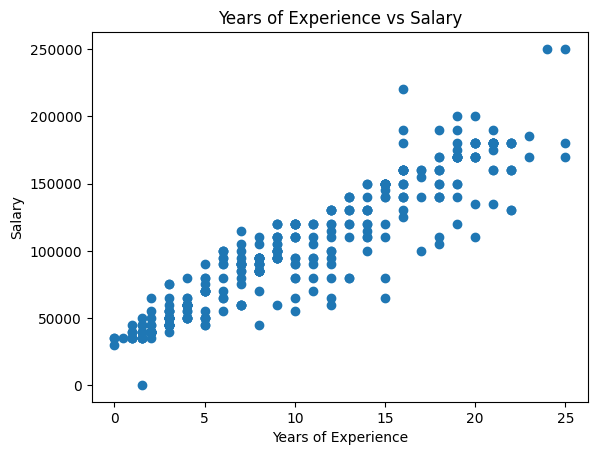

In [329]:
#Shwoing Feature Dependency of YOE VS Salary
plt.scatter(salary_df["Years of Experience"],salary_df["Salary"])
plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()


Conclusion:as Year of Experice increases the salary also increases


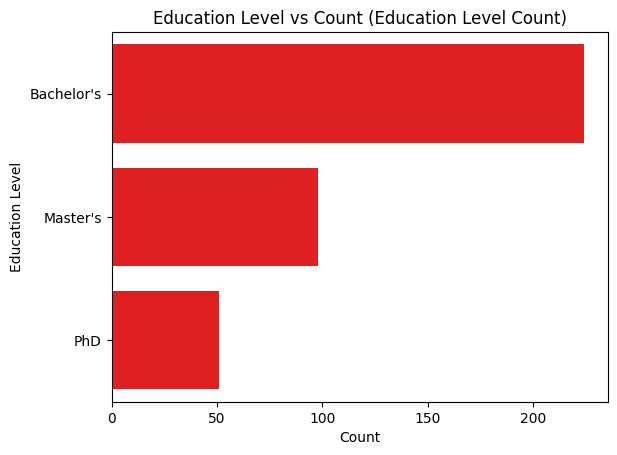

In [330]:
#Showing asHow many Bachelors People ,Master People and PHD People are there
sns.countplot(salary_df["Education Level"],color="r")
plt.title("Education Level vs Count (Education Level Count)")
plt.xlabel("Count")
plt.ylabel("Education Level")
plt.show()

In [331]:
#Showing Gneder Distribution in Pie Chart
gender_distribution = salary_df["Gender"].value_counts(normalize=True)*100

In [332]:
gender_distribution

,proportion
Gender,
Male,52.010724
Female,47.989276


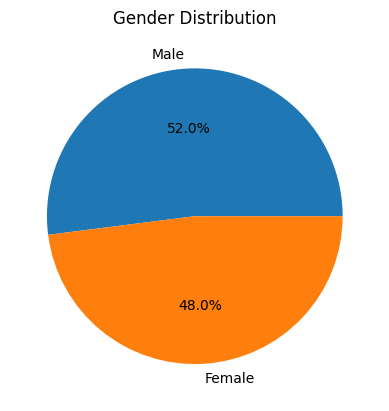

In [333]:
plt.pie(gender_distribution.values,labels=gender_distribution.index,autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.show()

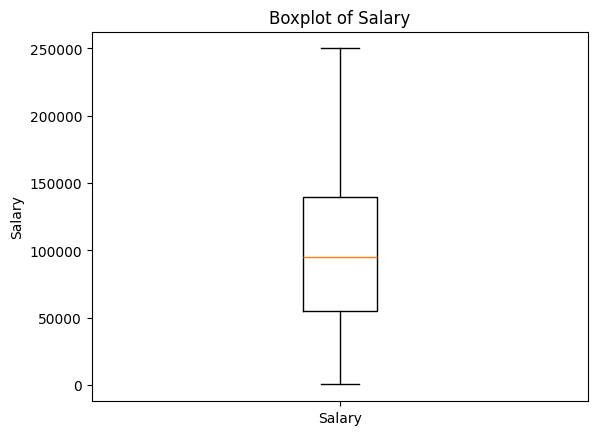

In [334]:
#Shwoing the Salary Boxplot
plt.boxplot(salary_df["Salary"],label=True)
plt.title("Boxplot of Salary")
plt.xticks([1], ["Salary"])
plt.ylabel("Salary")
plt.show()

# **Preprocessing Part of Gender,Education Level,Job Title**

In [335]:

salary_df["Gender"] = salary_df["Gender"].map({"Male":0,"Female":1})

In [336]:
salary_df["Education Level"].unique()

array(["Bachelor's", "Master's", 'PhD'], dtype=object)

In [337]:
salary_df["Education Level"] = salary_df["Education Level"].map({
    "Bachelor's": 0,
    "Master's": 1,
    "PhD": 2
})

In [338]:
job_dummies = pd.get_dummies(salary_df["Job Title"]).astype(int)

In [339]:

salary_df = pd.concat([salary_df, job_dummies], axis=1)

In [340]:
salary_df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Account Manager,Accountant,Administrative Assistant,Business Analyst,...,Supply Chain Manager,Technical Recruiter,Technical Support Specialist,Technical Writer,Training Specialist,UX Designer,UX Researcher,VP of Finance,VP of Operations,Web Developer
0,32.0,0,0,Software Engineer,5.0,90000.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,28.0,1,1,Data Analyst,3.0,65000.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,45.0,0,2,Senior Manager,15.0,150000.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,36.0,1,0,Sales Associate,7.0,60000.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,52.0,0,1,Director,20.0,200000.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,35.0,1,0,Senior Marketing Analyst,8.0,85000.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
371,43.0,0,1,Director of Operations,19.0,170000.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372,29.0,1,0,Junior Project Manager,2.0,40000.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
373,34.0,0,0,Senior Operations Coordinator,7.0,90000.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [341]:

salary_df.drop("Job Title", axis=1, inplace=True)

In [342]:
salary_df.columns

Index(['Age', 'Gender', 'Education Level', 'Years of Experience', 'Salary',
       'Account Manager', 'Accountant', 'Administrative Assistant',
       'Business Analyst', 'Business Development Manager',
       ...
       'Supply Chain Manager', 'Technical Recruiter',
       'Technical Support Specialist', 'Technical Writer',
       'Training Specialist', 'UX Designer', 'UX Researcher', 'VP of Finance',
       'VP of Operations', 'Web Developer'],
      dtype='object', length=179)

# **Training and Testing Data Splliting **

In [343]:
#Selecting the x and y features
x = salary_df.drop("Salary",axis=1)
y = salary_df["Salary"]

In [344]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [345]:
type(x_train),type(x_test)

(pandas.core.frame.DataFrame, pandas.core.frame.DataFrame)

In [346]:
type(y_train),type(y_test)

(pandas.core.series.Series, pandas.core.series.Series)

# **Converting the Pandas datafranme to Tensor to go in the Model**

In [347]:
x_train = torch.tensor(x_train.values, dtype=torch.float32)
x_test = torch.tensor(x_test.values, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)

In [348]:
type(x_train),type(x_test)

(torch.Tensor, torch.Tensor)

In [349]:
type(y_train),type(y_test)

(torch.Tensor, torch.Tensor)

In [350]:
x_train.shape,x_test.shape

(torch.Size([298, 178]), torch.Size([75, 178]))

In [351]:
y_train.shape,y_test.shape

(torch.Size([298]), torch.Size([75]))

# **Deep Learning Pipeline Start Making Class**

In [352]:
class SalaryModel(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.layer_1 = nn.Linear(in_features=178,out_features=128)
    self.layer_2 = nn.Linear(in_features=128,out_features=1)
  def forward(self,x):
    return self.layer_2(self.layer_1(x))

In [353]:
model = SalaryModel()

# **Loss Function and Optimizer Object Iniatlizes**

In [354]:
#Loss Fucntion and Optimizer initalZes object
loss_fn = nn.L1Loss()


In [355]:
optimizer = torch.optim.SGD(params = model.parameters(),lr=0.01)

# **Training and Testing Loop**

In [356]:
train_loss=0
def train_loop(model:torch.nn.Module,loss_fn,optimizer):
  #traing the model
  model.train()

  y_pred_train = model(x_train).squeeze(1)

  train_loss = loss_fn(y_pred_train,y_train)

  optimizer.zero_grad()

  #backpropogation
  train_loss.backward()

  optimizer.step()

  mae = MeanAbsoluteError()
  mae_result = mae(y_pred_train,y_train)
  mse = MeanSquaredError()
  mse_result = mse(y_pred_train,y_train)
  r2_score = R2Score()
  result_r2_score_train = r2_score(y_pred_train,y_train)

  print(f"MAE:{mae_result} | MSE:{mse_result} | R2 SCORE:{result_r2_score_train}")
  return train_loss,result_r2_score_train

In [372]:
def test_loop(model:torch.nn.Module,loss_fn,optimizer):
  model.eval()
  with torch.inference_mode():
    y_pred_test = model(x_test).squeeze(1)
    test_loss = loss_fn(y_pred_test,y_test)

  mae = MeanAbsoluteError()
  mae_result = mae(y_pred_test,y_test)
  mse = MeanSquaredError()
  mse_result = mse(y_pred_test,y_test)
  r2_score = R2Score()
  result_r2_score_test = r2_score(y_pred_test,y_test)


  print(f"Test Loss :{test_loss} | MAE:{mae_result} | MSE:{mse_result} | R2 Score:{result_r2_score_test}")
  return test_loss,result_r2_score_test

# **Calling Function and Showing and Train and Test Loss**

In [375]:
#prediction
NUM_EPOCHS=100
training_loss = []
testing_loss = []
r2_Score_train = []
r2_Score_test = []
for epoch in tqdm(range(NUM_EPOCHS)):
  train_loss,r2_Score = train_loop(model=model,loss_fn=loss_fn,optimizer=optimizer)
  training_loss.append(train_loss.detach().numpy())
  r2_Score_train.append(r2_Score.detach().numpy())
  test_loss,r2_Score = test_loop(model=model,loss_fn=loss_fn,optimizer=optimizer)
  testing_loss.append(test_loss.detach().numpy())
  r2_Score_test.append(r2_Score.detach().numpy())

  0%|          | 0/100 [00:00<?, ?it/s]

MAE:25163.982421875 | MSE:977545664.0 | R2 SCORE:0.5750589370727539
Test Loss :49744.1171875 | MAE:49744.1171875 | MSE:2977284864.0 | R2 Score:-0.24178683757781982
MAE:47116.5703125 | MSE:2756872448.0 | R2 SCORE:-0.1984180212020874
Test Loss :11457.1494140625 | MAE:11457.1494140625 | MSE:232131600.0 | R2 Score:0.9031809568405151
MAE:12130.4638671875 | MSE:312658080.0 | R2 SCORE:0.8640868663787842
Test Loss :11371.205078125 | MAE:11371.205078125 | MSE:231512560.0 | R2 Score:0.9034391045570374
MAE:12102.6474609375 | MSE:314378336.0 | R2 SCORE:0.8633390665054321
Test Loss :11451.2353515625 | MAE:11451.2353515625 | MSE:233440544.0 | R2 Score:0.9026349782943726
MAE:12080.724609375 | MSE:313069408.0 | R2 SCORE:0.863908052444458
Test Loss :11172.96875 | MAE:11172.96875 | MSE:232141536.0 | R2 Score:0.9031767845153809
MAE:12235.0986328125 | MSE:329658528.0 | R2 SCORE:0.8566967248916626
Test Loss :13907.16015625 | MAE:13907.16015625 | MSE:319040480.0 | R2 Score:0.8669323921203613
MAE:14230.80175

In [376]:
def plot_prediction(train_data = x_train,train_labels = y_train,test_data=x_test,test_labels=y_test,prediction=None):
  '''For plotting the prediction'''
  plt.figure(figsize=(10,7))
  plt.scatter(x_train,train_labels,c="b",label="Training Data")
  plt.scatter(x_test,test_labels,c="g",label="Testing Data")

  if prediction is not None:
    plt.scatter(test_data,prediction,c="r",label="Prediction")
  plt.legend(prop={"size":4})

In [413]:
y_prediction = final_prediction()

# **Final Prediction Part**

In [402]:
#prediction
def final_prediction():
  model.eval()
  with torch.inference_mode():
    y_pred = model(x_test).squeeze(1)
    return y_pred
def metrics_eval(y_pred):
  mae = MeanAbsoluteError()
  mae_result = mae(y_pred,y_test)
  mse = MeanSquaredError()
  mse_result = mse(y_pred,y_test)
  r2_score = R2Score()
  result_r2_score_final = r2_score(y_pred,y_test)
  print(f"MAE:{mae_result} | MSE:{mse_result} | R2 SCORE: {result_r2_score_final}")


In [407]:
y_prediction = final_prediction()
y_prediction.shape

torch.Size([75])

In [408]:
prediction_metrics = metrics_eval(y_prediction)
y_test.shape

MAE:25616.97265625 | MSE:915497152.0 | R2 SCORE: 0.6181580424308777


torch.Size([75])

# **Plotting the Curves Of Loss,R2 Score,Actual vs Predicted**

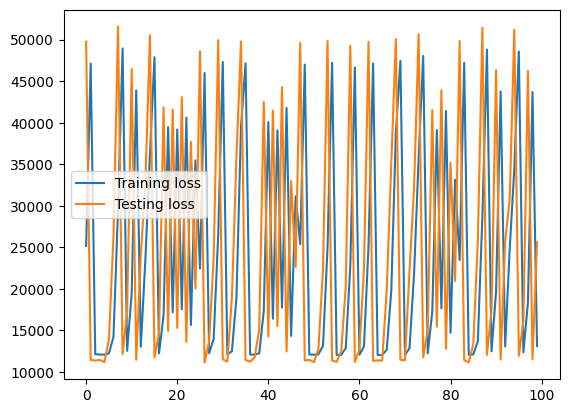

In [380]:
plt.plot(training_loss,label="Training loss")
plt.plot(testing_loss,label="Testing loss")
plt.legend()

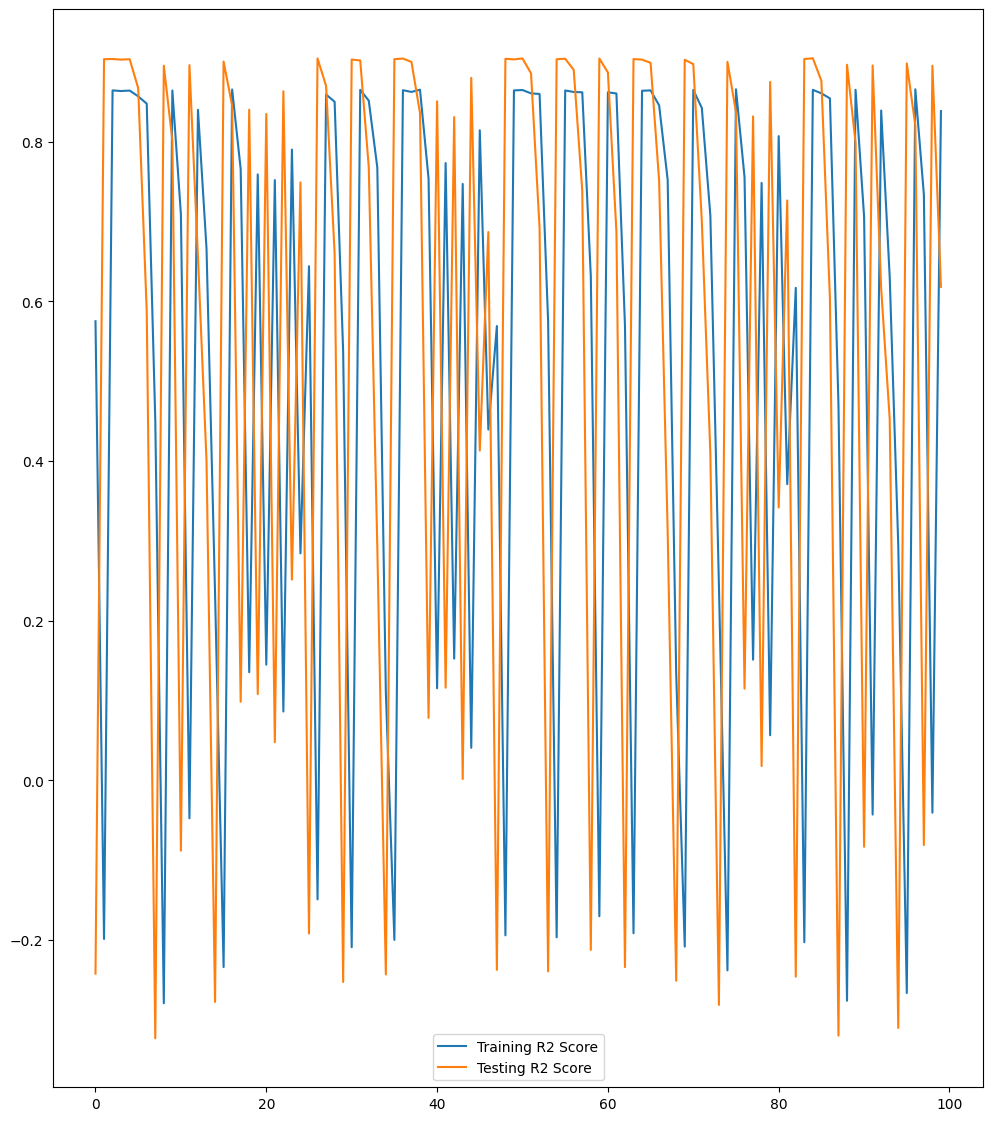

In [381]:
plt.figure(figsize=(12,14))
plt.plot(r2_Score_train,label="Training R2 Score")
plt.plot(r2_Score_test,label="Testing R2 Score")
plt.legend()

In [397]:
range(len(y_test))

range(0, 75)

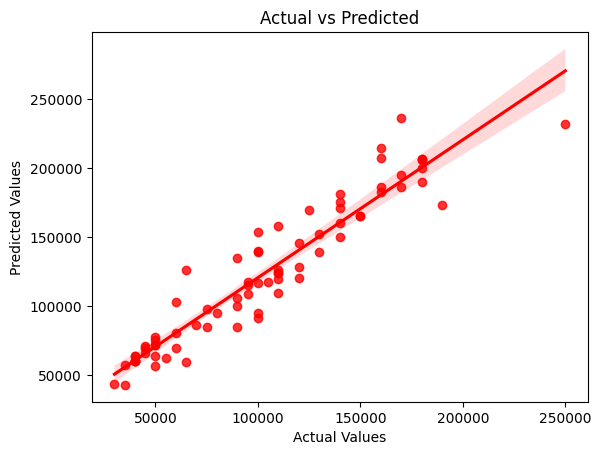

In [410]:


sns.regplot(x=y_test.numpy(), y=y_pred.numpy(),color="r")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()